# Factor Exploration with Qlib

This notebook demonstrates factor engineering using Qlib's expression engine.

**Objectives:**
1. Generate candidate factors using expression engine
2. Evaluate factor quality (IC, ICIR)
3. Select top-performing factors
4. Export features for model training

In [21]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from factor_generator import FactorGenerator
from feature_evaluator import FeatureEvaluator

%matplotlib inline
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

## 1. Generate Factor Library

In [22]:
# Initialize factor generator
generator = FactorGenerator()

# Generate all factor types
all_factors = generator.generate_all_factors()

# Print summary
print("Factor Generation Summary:")
print("-" * 60)
total = 0
for category, factors in all_factors.items():
    count = len(factors)
    total += count
    print(f"{category.capitalize():15s}: {count:4d} factors")
print("-" * 60)
print(f"{'Total':15s}: {total:4d} factors")

INFO:factor_generator:Generated 36 lag factors
INFO:factor_generator:Generated 100 rolling statistics factors
INFO:factor_generator:Generated 12 momentum factors
INFO:factor_generator:Generated 24 volatility factors
INFO:factor_generator:Generated 12 z-score factors
INFO:factor_generator:Generated 16 ratio/difference factors
INFO:factor_generator:Generated 9 technical indicator factors
INFO:factor_generator:Generated 18 quantile factors
INFO:factor_generator:Generated 227 total factors across 8 types


Factor Generation Summary:
------------------------------------------------------------
Lag            :   36 factors
Rolling        :  100 factors
Momentum       :   12 factors
Volatility     :   24 factors
Zscore         :   12 factors
Ratio          :   16 factors
Technical      :    9 factors
Quantile       :   18 factors
------------------------------------------------------------
Total          :  227 factors


In [23]:
# Show example factors from each category
print("\nExample Factors:")
print("=" * 80)
for category, factors in all_factors.items():
    print(f"\n{category.upper()}:")
    for name, expr in factors[:5]:  # Show first 5
        print(f"  {name:40s} = {expr}")


Example Factors:

LAG:
  LAG_M1_T1                                = Ref($M1, 1)
  LAG_M1_T2                                = Ref($M1, 2)
  LAG_M1_T5                                = Ref($M1, 5)
  LAG_M1_T10                               = Ref($M1, 10)
  LAG_M1_T20                               = Ref($M1, 20)

ROLLING:
  ROLL_MEAN_M1_W5                          = Mean($M1, 5)
  ROLL_STD_M1_W5                           = Std($M1, 5)
  ROLL_MAX_M1_W5                           = Max($M1, 5)
  ROLL_MIN_M1_W5                           = Min($M1, 5)
  ROLL_MEDIAN_M1_W5                        = Median($M1, 5)

MOMENTUM:
  MOM_M1_T5                                = ($M1 - Ref($M1, 5)) / Ref($M1, 5)
  MOM_M1_T10                               = ($M1 - Ref($M1, 10)) / Ref($M1, 10)
  MOM_M1_T20                               = ($M1 - Ref($M1, 20)) / Ref($M1, 20)
  MOM_M1_T60                               = ($M1 - Ref($M1, 60)) / Ref($M1, 60)
  MOM_P1_T5                                = ($P1 - Ref($

In [24]:
# Export factor library
df_factors = generator.export_factor_list(all_factors, '../outputs/factor_library.csv')
print(f"\nExported {len(df_factors)} factors to factor_library.csv")
df_factors.head(10)

INFO:factor_generator:Exported 227 factors to ../outputs/factor_library.csv



Exported 227 factors to factor_library.csv


,factor_name,expression,category
0,LAG_M1_T1,"Ref($M1, 1)",lag
1,LAG_M1_T2,"Ref($M1, 2)",lag
2,LAG_M1_T5,"Ref($M1, 5)",lag
3,LAG_M1_T10,"Ref($M1, 10)",lag
4,LAG_M1_T20,"Ref($M1, 20)",lag
5,LAG_M1_T60,"Ref($M1, 60)",lag
6,LAG_V1_T1,"Ref($V1, 1)",lag
7,LAG_V1_T2,"Ref($V1, 2)",lag
8,LAG_V1_T5,"Ref($V1, 5)",lag
9,LAG_V1_T10,"Ref($V1, 10)",lag


## 2. Load Data and Compute Factors

**This section computes 200+ factors manually (without Qlib).**

We use the `compute_all_factors` module to generate:
- Lag features (6 periods × 4 features = 24)
- Rolling statistics (5 stats × 5 windows × 4 features = 100)
- Momentum features (4 periods × 4 features = 16)
- Volatility features (2 types × 4 windows × 4 features = 32)
- Z-score features (3 windows × 4 features = 12)
- Ratio features (~8 cross-feature combinations)
- Technical indicators (3 types × 4 features = 12)
- Quantile features (3 quantiles × 2 windows × 4 features = 24)

**Total: ~200-220 factors**

For production use with Qlib, you would:
1. Initialize Qlib with your data
2. Use DataHandler with factor expressions from Section 1
3. Qlib will compute factors using its optimized expression engine

In [25]:
# Load processed data
df = pd.read_csv('../data/processed/SP500.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Data shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.head()

Data shape: (8990, 98)
Date range: 1990-01-01 00:00:00 to 2014-08-12 00:00:00


,date,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,1990-01-01,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1990-01-02,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,1990-01-03,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,1990-01-04,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,1990-01-05,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301


In [26]:
# Import comprehensive factor computation module
from compute_all_factors import compute_all_factors, get_computed_factor_names

# Compute ALL factors (200+ factors)
print("Computing comprehensive factor set...")
print("This may take 30-60 seconds...\n")

df_with_factors = compute_all_factors(df, base_features=['M1', 'V1', 'P1', 'S1'])

# Get list of new factor columns
factor_cols = get_computed_factor_names(df, df_with_factors)
print(f"\nComputed {len(factor_cols)} factors")
print(f"\nFirst 20 factors:")
for i, factor in enumerate(factor_cols[:20], 1):
    print(f"  {i:2d}. {factor}")

Computing comprehensive factor set...
This may take 30-60 seconds...

Computing factors for 4 base features...
  - Lag features...
  - Rolling statistics...
  - Momentum features...
  - Volatility features...
  - Z-score features...
  - Ratio features...
  - Technical indicators...
  - Quantile features...

✓ Computed 228 factors
  DataFrame shape: (8990, 98) → (8990, 326)

Computed 228 factors

First 20 factors:
   1. DIFF_M1_SUB_M2
   2. DIFF_M1_SUB_M3
   3. DIFF_P1_SUB_P2
   4. DIFF_V1_SUB_V2
   5. LAG_M1_T1
   6. LAG_M1_T10
   7. LAG_M1_T2
   8. LAG_M1_T20
   9. LAG_M1_T5
  10. LAG_M1_T60
  11. LAG_P1_T1
  12. LAG_P1_T10
  13. LAG_P1_T2
  14. LAG_P1_T20
  15. LAG_P1_T5
  16. LAG_P1_T60
  17. LAG_S1_T1
  18. LAG_S1_T10
  19. LAG_S1_T2
  20. LAG_S1_T20


## 3. Evaluate Factors

In [27]:
# Initialize evaluator
evaluator = FeatureEvaluator(target_col='market_forward_excess_returns')

# Evaluate all factors
# Note: This will only work if target column exists and factors are valid
if 'market_forward_excess_returns' in df_with_factors.columns and len(factor_cols) > 0:
    # Filter out factors with too many NaNs
    valid_factors = []
    for col in factor_cols:
        if df_with_factors[col].notna().sum() > 100:  # At least 100 valid values
            valid_factors.append(col)
    
    print(f"Evaluating {len(valid_factors)} valid factors...")
    
    df_eval = evaluator.evaluate_factor_batch(
        df_with_factors,
        valid_factors,
        ic_window=20,
        ic_method='spearman'
    )
    
    print("\nTop 20 Factors by |IC|:")
    display(df_eval.head(20))
else:
    print("Target column not found or no valid factors. Skipping evaluation.")

Evaluating 228 valid factors...


INFO:feature_evaluator:Evaluated 228 factors



Top 20 Factors by |IC|:


,factor,ic,icir,autocorr_1,autocorr_5,missing_ratio,mean,std,min,max,abs_ic
152,ROLL_STD_M1_W10,0.065268,0.300672,0.949873,0.527563,0.618020,0.215117,0.133674,0.024067,1.296308,0.065268
216,ZSCORE_M1_W120,0.056816,0.977262,0.925939,0.744401,0.630256,-0.127854,1.222809,-2.803052,6.657642,0.056816
75,ROLL_MAX_M1_W5,0.055782,1.061999,0.990397,0.923004,0.617464,-0.406913,1.037720,-2.367140,5.125899,0.055782
72,ROLL_MAX_M1_W10,0.055687,0.903664,0.992841,0.941759,0.618020,-0.265272,1.053972,-2.320931,5.125899,0.055687
95,ROLL_MEAN_M1_W5,0.052934,1.070092,0.996534,0.947930,0.617464,-0.616507,0.982431,-2.435197,4.249810,0.052934
115,ROLL_MEDIAN_M1_W5,0.052179,1.070149,0.993837,0.943195,0.617464,-0.623002,0.988791,-2.425817,4.431522,0.052179
155,ROLL_STD_M1_W5,0.051845,0.356666,0.845109,0.297849,0.617464,0.164999,0.116317,0.007983,1.150880,0.051845
4,LAG_M1_T1,0.050586,0.863996,0.974691,0.916200,0.617130,-0.615464,0.999816,-2.522870,5.125899,0.050586
6,LAG_M1_T2,0.050074,0.737069,0.974689,0.916193,0.617241,-0.615266,0.999894,-2.522870,5.125899,0.050074
112,ROLL_MEDIAN_M1_W10,0.047431,0.959684,0.997457,0.962787,0.618020,-0.631482,0.974035,-2.390596,3.422476,0.047431


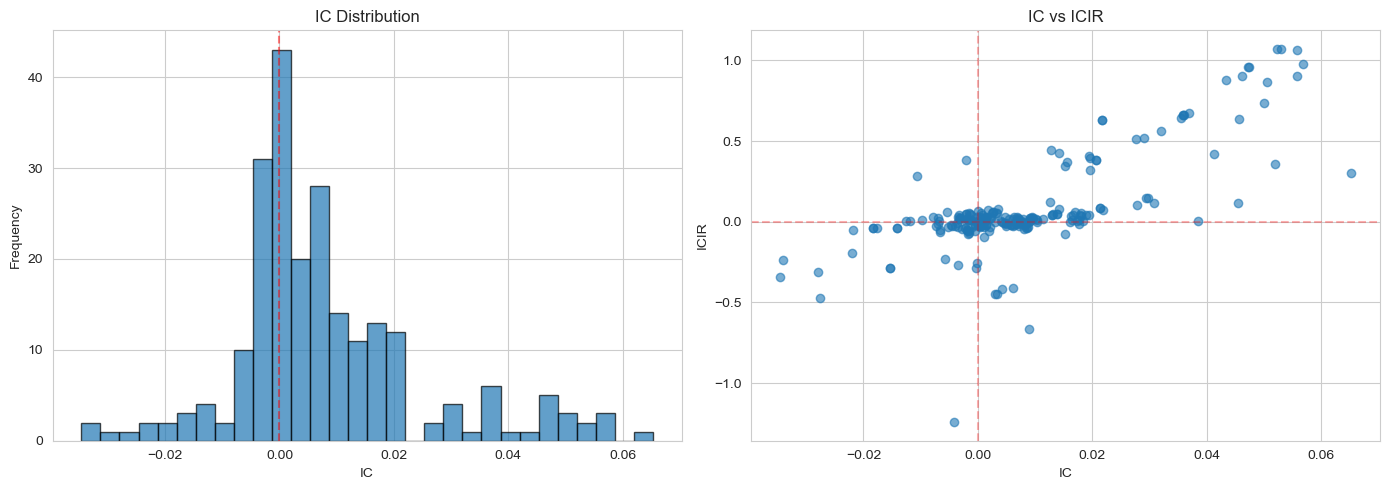

In [28]:
# Visualize IC distribution
if 'df_eval' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # IC histogram
    axes[0].hist(df_eval['ic'].dropna(), bins=30, alpha=0.7, edgecolor='black')
    axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('IC')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('IC Distribution')
    
    # IC vs ICIR scatter
    axes[1].scatter(df_eval['ic'], df_eval['icir'], alpha=0.6)
    axes[1].axvline(0, color='red', linestyle='--', alpha=0.3)
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.3)
    axes[1].set_xlabel('IC')
    axes[1].set_ylabel('ICIR')
    axes[1].set_title('IC vs ICIR')
    
    plt.tight_layout()
    plt.show()

## 4. Analyze Factor Quality

In [29]:
if 'df_eval' in locals():
    # Summary statistics
    print("Factor Quality Summary:")
    print("-" * 60)
    print(f"Total factors evaluated: {len(df_eval)}")
    print(f"Mean |IC|: {df_eval['abs_ic'].mean():.4f}")
    print(f"Median |IC|: {df_eval['abs_ic'].median():.4f}")
    print(f"Max |IC|: {df_eval['abs_ic'].max():.4f}")
    print(f"Factors with |IC| > 0.02: {(df_eval['abs_ic'] > 0.02).sum()}")
    print(f"Factors with |IC| > 0.05: {(df_eval['abs_ic'] > 0.05).sum()}")
    print(f"Positive IC ratio: {(df_eval['ic'] > 0).mean():.2%}")
    print(f"\nMean ICIR: {df_eval['icir'].mean():.4f}")
    print(f"Factors with ICIR > 1: {(df_eval['icir'] > 1).sum()}")

Factor Quality Summary:
------------------------------------------------------------
Total factors evaluated: 228
Mean |IC|: 0.0121
Median |IC|: 0.0070
Max |IC|: 0.0653
Factors with |IC| > 0.02: 42
Factors with |IC| > 0.05: 9
Positive IC ratio: 69.74%

Mean ICIR: 0.0741
Factors with ICIR > 1: 3


In [30]:
# Analyze by factor category
if 'df_eval' in locals():
    # Extract category from factor name
    df_eval['category'] = df_eval['factor'].str.split('_').str[0]
    
    category_stats = df_eval.groupby('category').agg({
        'ic': ['mean', 'std'],
        'abs_ic': 'mean',
        'icir': 'mean',
        'factor': 'count'
    }).round(4)
    
    print("\nFactor Performance by Category:")
    display(category_stats)


Factor Performance by Category:


ic          abs_ic    icir factor
            mean     std    mean    mean  count
category                                       
DIFF      0.0073  0.0218  0.0147 -0.2439      4
LAG       0.0100  0.0165  0.0115  0.0878     24
MOM      -0.0014  0.0185  0.0145 -0.0440     16
QUANTILE  0.0084  0.0122  0.0098  0.1277     24
RATIO     0.0055  0.0212  0.0165 -0.1838      4
ROLL      0.0111  0.0173  0.0125  0.1413    100
TECH      0.0001  0.0165  0.0138  0.0057     12
VOL       0.0044  0.0089  0.0076 -0.0769     32
ZSCORE    0.0068  0.0247  0.0194  0.2002     12

## 5. Select Top Factors

In [31]:
if 'df_eval' in locals():
    # Select factors with high IC and low correlation
    # Strategy 1: Top N by |IC|
    top_n = 50
    top_factors_by_ic = df_eval.head(top_n)['factor'].tolist()
    
    print(f"\nTop {top_n} factors by |IC|:")
    for i, factor in enumerate(top_factors_by_ic[:10], 1):
        ic = df_eval[df_eval['factor'] == factor]['ic'].values[0]
        print(f"{i:2d}. {factor:40s} IC={ic:.4f}")
    
    # Strategy 2: Remove highly correlated factors
    print(f"\nRemoving highly correlated factors (threshold=0.8)...")
    selected_factors = evaluator.select_low_correlation_features(
        df_with_factors,
        top_factors_by_ic,
        threshold=0.8
    )
    print(f"Selected {len(selected_factors)} uncorrelated factors")


Top 50 factors by |IC|:
 1. ROLL_STD_M1_W10                          IC=0.0653
 2. ZSCORE_M1_W120                           IC=0.0568
 3. ROLL_MAX_M1_W5                           IC=0.0558
 4. ROLL_MAX_M1_W10                          IC=0.0557
 5. ROLL_MEAN_M1_W5                          IC=0.0529
 6. ROLL_MEDIAN_M1_W5                        IC=0.0522
 7. ROLL_STD_M1_W5                           IC=0.0518
 8. LAG_M1_T1                                IC=0.0506
 9. LAG_M1_T2                                IC=0.0501
10. ROLL_MEDIAN_M1_W10                       IC=0.0474

Removing highly correlated factors (threshold=0.8)...


INFO:feature_evaluator:Selected 20/50 features (removed 30 highly correlated)


Selected 20 uncorrelated factors


## 6. Generate Evaluation Report

In [32]:
if 'df_eval' in locals() and 'selected_factors' in locals():
    # Generate comprehensive report
    report = evaluator.generate_evaluation_report(
        df_with_factors,
        selected_factors,
        output_path='../outputs/reports/factor_evaluation_report.csv'
    )
    
    print("\nEvaluation Report Summary:")
    for key, value in report['summary'].items():
        print(f"  {key:25s}: {value:.4f}")

INFO:feature_evaluator:Generating evaluation report...
INFO:feature_evaluator:Evaluated 20 factors
INFO:feature_evaluator:Report saved to ../outputs/reports/factor_evaluation_report.csv



Evaluation Report Summary:
  total_factors            : 20.0000
  mean_ic                  : 0.0169
  median_ic                : 0.0218
  mean_abs_ic              : 0.0337
  max_abs_ic               : 0.0653
  mean_icir                : 0.1362
  positive_ic_ratio        : 0.7000


## 7. Export Features for Model Training

In [33]:
if 'selected_factors' in locals():
    # Create feature dataframe
    feature_cols_export = ['date'] + selected_factors + ['market_forward_excess_returns']
    df_export = df_with_factors[feature_cols_export].copy()
    
    # Save
    output_path = '../outputs/features/selected_features.csv'
    df_export.to_csv(output_path, index=False)
    print(f"Exported {len(selected_factors)} features to {output_path}")
    
    # Save feature list
    feature_list_path = '../outputs/features/feature_list.txt'
    with open(feature_list_path, 'w') as f:
        for feature in selected_factors:
            f.write(f"{feature}\n")
    print(f"Saved feature list to {feature_list_path}")

Exported 20 features to ../outputs/features/selected_features.csv
Saved feature list to ../outputs/features/feature_list.txt


## Next Steps

1. Use selected features in main training notebook
2. Train models with engineered features
3. Iterate on factor design based on model performance
4. For production: Set up Qlib with proper data initialization